In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [9]:
output_path = '../figures/'
# df = pd.read_csv(f'../data/INDI_database/raw_embeddings.tsv', sep='\t')
df = pd.read_csv(f'/data1/dhuang/Ig-fold/nanobody_db/INDI_241125/tokenized_INDI_dedup_250609_2C/raw_embeddings.tsv', sep='\t')

df.rename(columns={df.columns[0]: 'pdb_id'}, inplace=True)


In [10]:

rows_with_nan = df[df.isnull().any(axis=1)]

if not rows_with_nan.empty:
    nan_indices = rows_with_nan.index
    df.drop(nan_indices, inplace=True)
    print("Removed NaN rows:")
    print(nan_indices)
else:
    print("None of the rows have NaN values")
    
# df.to_csv(f'{output_path}merged_tokenized_connectors.tsv', sep='\t', index=False)

None of the rows have NaN values


In [11]:
num_columns = len(df.columns)
connector_len = int((num_columns - 1) / 3)

connector1 = df.iloc[:, 1 : connector_len + 1]
connector2 = df.iloc[:, connector_len + 1 : connector_len*2 + 1]
connector3 = df.iloc[:, -connector_len:]


In [12]:
first_column = df.iloc[:, 0]  # ID
embeddings_data = df.iloc[:, 1:]  # embedding

scaler = StandardScaler()

# Z-score
scaled_data = scaler.fit_transform(embeddings_data)
scaled_df = pd.DataFrame(scaled_data, columns=embeddings_data.columns)

# Add original IDs to the scaled dataframe
full_scaled_df = pd.concat([first_column.reset_index(drop=True), scaled_df], axis=1)
# full_scaled_df.to_csv(f'{output_path}merged_tokenized_connectors_scaled.tsv', sep='\t', index=False)

# num_columns = len(full_scaled_df.columns)
# connector_len = int((num_columns - 1) / 3)

# connector1 = full_scaled_df.iloc[:, 1 : connector_len + 1]
# connector2 = full_scaled_df.iloc[:, connector_len + 1 : connector_len*2 + 1]
# connector3 = full_scaled_df.iloc[:, -connector_len:]

Using non scaled connector embedding

In [ ]:

import matplotlib.pyplot as plt

cluster_df = pd.concat([first_column.reset_index(drop=True), embeddings_data], axis=1)

# 使用 KMeans 聚类
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)  # 假设聚成5类
cluster_df['Cluster'] = kmeans.fit_predict(cluster_df.iloc[:, 1:])

# 计算每个点到所属簇中心的距离
centers = kmeans.cluster_centers_
distances = np.linalg.norm(cluster_df.iloc[:, 1:-1].values - centers[cluster_df['Cluster']], axis=1)

# 添加距离列
cluster_df['Distance_to_Center'] = distances

# 找到每个簇中距离中心最近的点
closest_points = cluster_df.loc[cluster_df.groupby('Cluster')['Distance_to_Center'].idxmin()]

# 输出最近点的信息（第1列是目标信息）
print("Closest points to cluster centers:")
print(closest_points[['pdb_id', 'Cluster', 'Distance_to_Center']])

# 查看聚类结果
# print(tocluster_df[['id', 'Cluster']])


# cluster_df[['pdb_id', 'Cluster']].to_csv(f'{output_path}merged_tokenized_connectors_scaled_cluster{n_clusters}.csv', index=False)


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import umap
import seaborn as sns

# UMAP 降维
n_neighbors = 15
min_dist = 0.5
umap_result = umap.UMAP(n_components=2, random_state=42, n_neighbors=n_neighbors, min_dist=min_dist).fit_transform(embeddings_data)
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Label'] = cluster_df.iloc[:, 0].values
umap_df['Cluster'] = cluster_df['Cluster']

# 使用Seaborn的tab20调色板，确保类别数不超过20
unique_clusters = sorted(umap_df['Cluster'].unique())  # 升序排序
palette = sns.color_palette("tab20", len(unique_clusters))

# 创建Cluster到颜色的映射
cluster_colors = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

# 根据Cluster为UMAP数据点分配颜色
umap_df['Color'] = umap_df['Cluster'].map(cluster_colors)

# 绘制UMAP图
plt.figure(figsize=(8, 6))
for cluster in unique_clusters:
    cluster_data = umap_df[umap_df['Cluster'] == cluster]
    plt.scatter(cluster_data['UMAP1'], cluster_data['UMAP2'], label=f'Cluster {cluster}', 
                color=cluster_colors[cluster], alpha=0.7)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', 
           handles=[plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}', 
                               markerfacecolor=cluster_colors[cluster], markersize=10) 
                    for cluster in unique_clusters])

plt.title('UMAP Result')
plt.xlabel('UMAP_1')
plt.ylabel('UMAP_2')
plt.tight_layout()
# plt.savefig(f'{output_path}UMAP_connector3.png', dpi=600)
plt.show()


/home/dhuang/work/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'cluster_df' is not defined

## Plot selected dot

In [13]:
selected_df = pd.read_csv('/home/dhuang/work/Ig-fold/nanobody_db/INDI/cov_INDI_dupl_selected.tsv', sep='\t')
selected_pdb = selected_df['PDBChain']

/home/dhuang/work/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


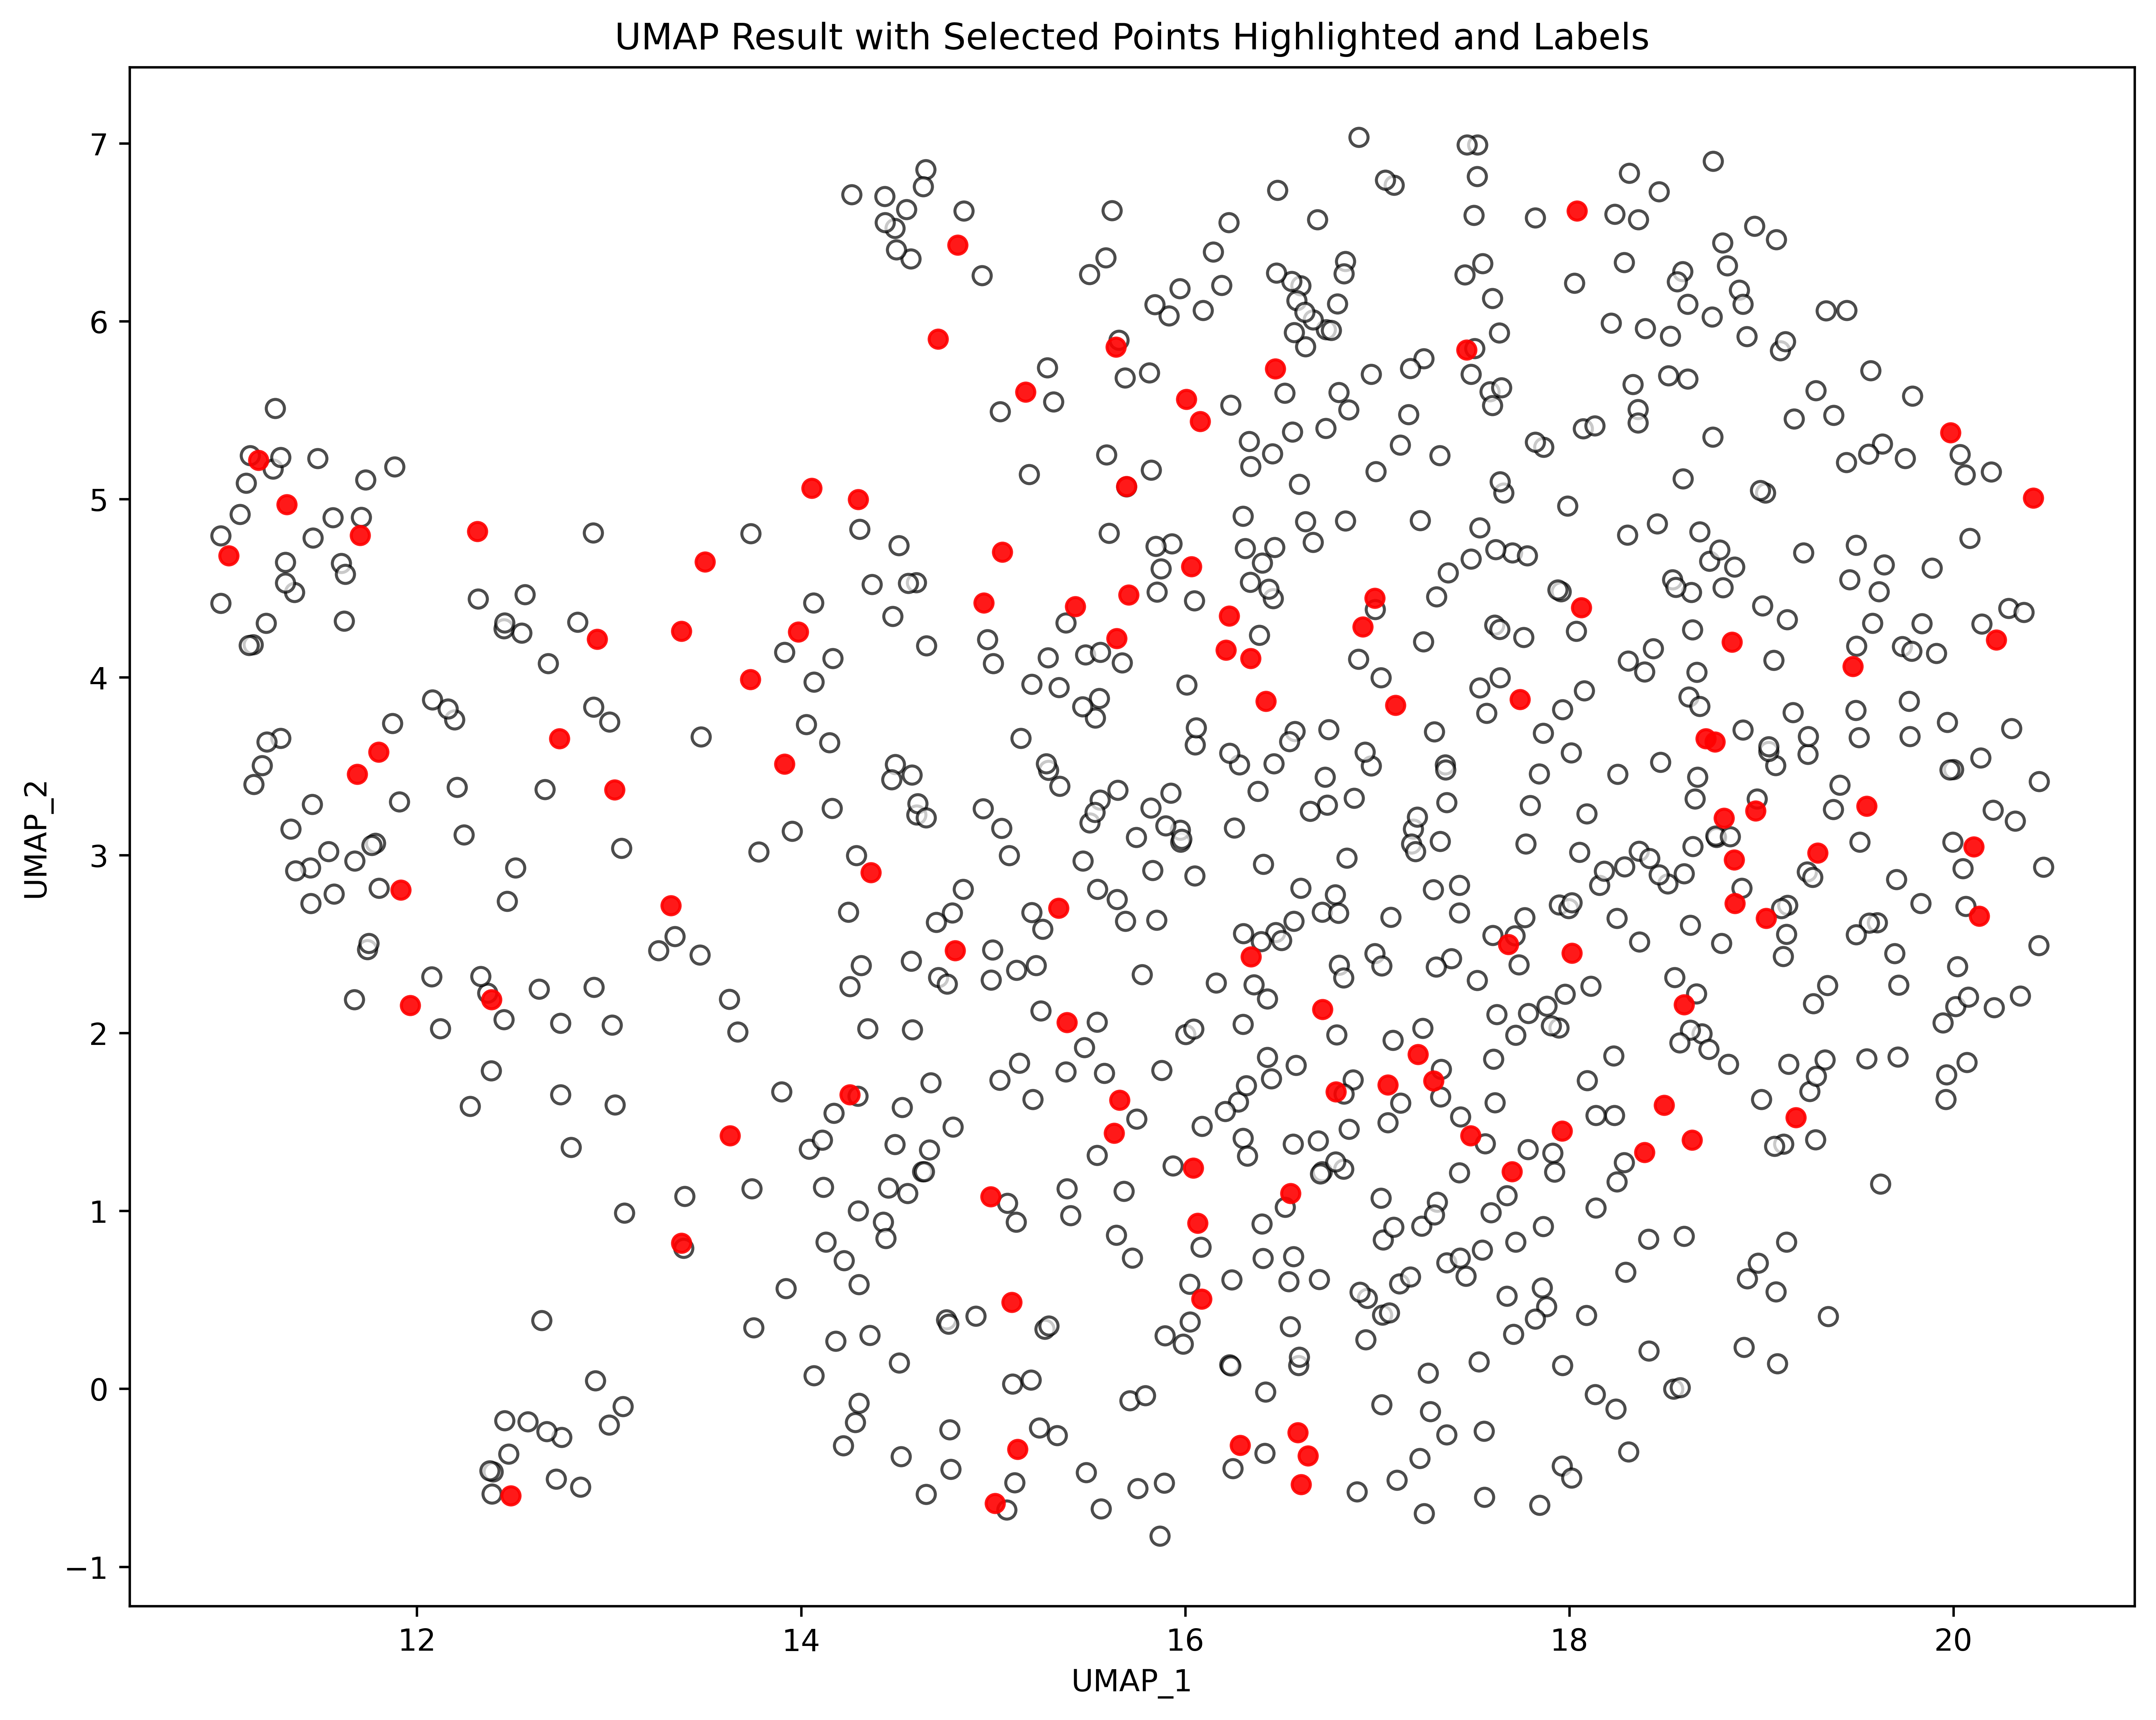

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import umap
import seaborn as sns

# 假设 connector3 是输入数据，cluster_df 是包含 Cluster 和 Label 信息的 DataFrame
# selected_pdb 是需要标记的 PDBChain 列表

# UMAP 降维
n_neighbors = 15
min_dist = 0.5
umap_result = umap.UMAP(n_components=2, random_state=42, n_neighbors=n_neighbors, min_dist=min_dist).fit_transform(connector3)
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Label'] = full_scaled_df.iloc[:, 0].values  # 添加 Label 信息
# umap_df['Cluster'] = full_scaled_df['Cluster']

# # 使用Seaborn的tab20调色板，确保类别数不超过20
# unique_clusters = sorted(umap_df['Cluster'].unique())  # 升序排序
# palette = sns.color_palette("tab20", len(unique_clusters))

# # 创建Cluster到颜色的映射
# cluster_colors = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

# # 根据Cluster为UMAP数据点分配颜色
# umap_df['Color'] = umap_df['Cluster'].map(cluster_colors)

# 标记 selected_pdb 的点
umap_df['Is_Selected'] = umap_df['Label'].isin(selected_pdb)

# 绘制 UMAP 图
plt.figure(figsize=(10, 8), dpi=600)

# 绘制未选中的点（灰色）
non_selected_data = umap_df[~umap_df['Is_Selected']]
plt.scatter(non_selected_data['UMAP1'], non_selected_data['UMAP2'], color='white', alpha=0.7, edgecolor='black', label='Non-Selected')

# 绘制选中的点（红色）
selected_data = umap_df[umap_df['Is_Selected']]
plt.scatter(selected_data['UMAP1'], selected_data['UMAP2'], color='red', alpha=0.9, label='Selected')

# # 只为选中的点添加 Label 注释
# for _, row in selected_data.iterrows():
#     x, y, label = row['UMAP1'], row['UMAP2'], row['Label']
#     plt.annotate(
#         label, 
#         (x, y), 
#         textcoords="offset points",  # 使用偏移量定位文本
#         xytext=(5, 5),               # 文本相对于点的偏移量
#         ha='left',                   # 水平对齐方式
#         fontsize=8,                  # 字体大小
#         color=row['Color']   # 字体颜色
#     )

# # 添加图例
# plt.legend(title='Points', bbox_to_anchor=(1, 1), loc='upper left')
# plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', 
#            handles=[plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {cluster}', 
#                                markerfacecolor=cluster_colors[cluster], markersize=10) 
#                     for cluster in unique_clusters])

# 添加标题和坐标轴标签
plt.title('UMAP Result with Selected Points Highlighted and Labels')
plt.xlabel('UMAP_1')
plt.ylabel('UMAP_2')
plt.tight_layout()  # 自动调整子图参数，以给图例留出空间
# plt.savefig(f'{output_path}UMAP_connector3_selected_with_labels.png', dpi=600)
plt.show()

/tmp/ipykernel_2072783/3404330522.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_counts.index, y=selected_counts.values, palette=palette)


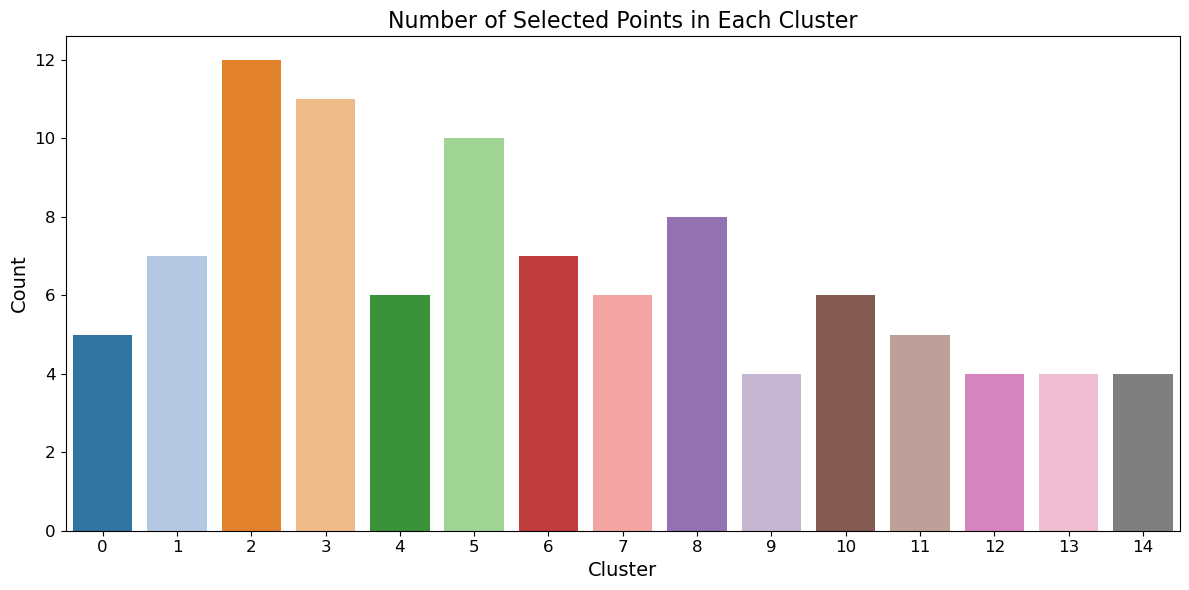

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设 umap_df 和 cluster_df 已经定义
# 添加 Label 和 Cluster 信息
umap_df['Label'] = cluster_df.iloc[:, 0].values  # 添加 Label 信息
umap_df['Cluster'] = cluster_df['Cluster']

# 标记 selected_pdb 的点
umap_df['Is_Selected'] = umap_df['Label'].isin(selected_pdb)

# 统计每个 Cluster 中 Is_Selected 为 True 的点的数量
selected_counts = umap_df[umap_df['Is_Selected']].groupby('Cluster').size()

# 如果某些 Cluster 没有 Is_Selected 为 True 的点，则填充为 0
all_clusters = umap_df['Cluster'].unique()
selected_counts = selected_counts.reindex(all_clusters, fill_value=0)

# 使用Seaborn的tab20调色板，确保类别数不超过20
unique_clusters = sorted(umap_df['Cluster'].unique())  # 升序排序
palette = sns.color_palette("tab20", len(unique_clusters))

# 绘制柱状图
plt.figure(figsize=(12, 6))
sns.barplot(x=selected_counts.index, y=selected_counts.values, palette=palette)
plt.title('Number of Selected Points in Each Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# 显示图形
plt.show()